# 05 — Deep Learning: MLP for Repeat-Purchase Prediction
**Member 4 — Deep Learning track**

This notebook is the *upgrade* half of the "classical ML baseline **and** a deep-learning
model" requirement. It deliberately reuses Member 3's dataset, feature list and train/test
split from `04_ml_models.ipynb`, because a model comparison is only meaningful when both
models see exactly the same data.

What it covers:
1. Dataset and the leakage-safe split (train / validation / test)
2. Why the target needs class weighting
3. The MLP architecture and every regularisation choice
4. Training with early stopping and learning-rate scheduling
5. Training curves
6. Threshold tuning (0.5 is the wrong cut-off for an imbalanced target)
7. Test-set evaluation and the ML vs DL comparison table
8. Saving a versioned artifact the Streamlit app and the agent can load

> **Read the results honestly.** This notebook runs on `data/sample.csv` (300 rows,
> 261 customers, ~25 repeat buyers). That is far too small for a neural network to beat a
> tuned random forest, and the numbers below show exactly that. Re-run the whole notebook on
> the full Online Retail II extract (~5,800 customers) before quoting any figure in the report.

## 1. Setup

In [1]:
from pathlib import Path
import sys, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make the repo root importable no matter where Jupyter was started
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os; os.chdir(ROOT)
print("repo root:", ROOT)

import torch
print("torch:", torch.__version__)

repo root: /home/claude/work/Enterprise-AI-Data-Analyst-main


torch: 2.14.0+cu130


In [2]:
from sklearn.model_selection import train_test_split

from src.features.engineering import build_repeat_purchase_dataset
from src.models.train import DEFAULT_FEATURES, build_models, evaluate_fitted, tune_random_forest
from src.models.dl import (
    MLPRepeatPurchaseModel, RepeatPurchaseMLP,
    train_mlp, tune_threshold, evaluate_mlp, save_dl_artifact,
)
from src.evaluation.metrics import classification_metrics

## 2. Dataset

Same feature builder as the classical track: one row per customer, predictors taken **only**
from that customer's first observed order. Anything derived from later orders would leak the
target (`repeat_customer` is defined as "more than one invoice").

In [3]:
raw = pd.read_csv("data/sample.csv")
dataset = build_repeat_purchase_dataset(raw)

X = dataset[DEFAULT_FEATURES].copy()
y = dataset["repeat_customer"].copy()

print("customers:", len(dataset))
print("features:", len(DEFAULT_FEATURES))
print("repeat rate:", round(y.mean(), 4))
dataset[["first_order_revenue", "first_order_quantity", "first_order_lines",
         "observed_order_count", "repeat_customer"]].describe().T

customers: 261
features: 9
repeat rate: 0.0958


,count,mean,std,min,25%,50%,75%,max
first_order_revenue,261.0,17.696820,26.941781,-102.0,3.9,14.85,19.8,211.2
first_order_quantity,261.0,10.636015,18.923980,-48.0,2.0,6.00,12.0,200.0
first_order_lines,261.0,1.015326,0.123081,1.0,1.0,1.00,1.0,2.0
observed_order_count,261.0,1.134100,0.497326,1.0,1.0,1.00,1.0,6.0
repeat_customer,261.0,0.095785,0.294862,0.0,0.0,0.00,0.0,1.0


### Class balance

The positive class is a small minority. Two consequences drive every choice later in this
notebook:

* **accuracy is useless** — a model predicting "never repeats" for everyone already scores
  ~90%, so PR-AUC (average precision), recall and F1 are the metrics reported;
* **the loss must be weighted** — otherwise gradient descent simply learns the majority class.

repeat_customer
0    236
1     25
Name: count, dtype: int64
imbalance ratio (neg:pos): 9.44


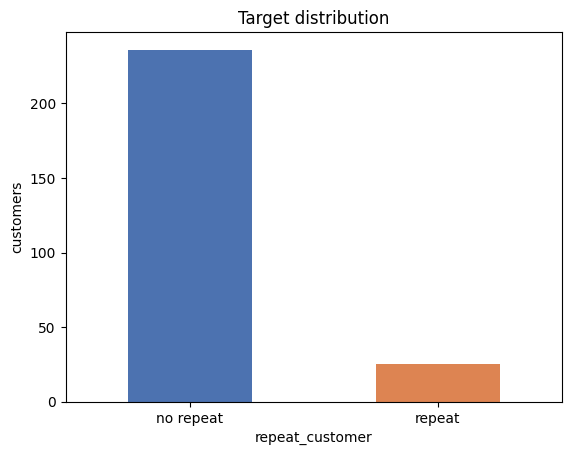

In [4]:
counts = y.value_counts().sort_index()
print(counts)
print("imbalance ratio (neg:pos):", round(counts[0] / max(counts[1], 1), 2))

counts.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["no repeat", "repeat"], rotation=0)
plt.ylabel("customers"); plt.title("Target distribution"); plt.show()

## 3. Leakage-safe split

Three splits, not two:

* **test (25%)** — touched exactly once, at the very end;
* **validation (20% of the remainder)** — drives early stopping, LR scheduling and the
  decision threshold;
* **train** — everything else.

Early stopping on the *test* set would be a silent leak: the stopping epoch would be chosen
using the data the final number is reported on. The classical models are refit on
train+validation so both tracks see the same amount of data.

In [5]:
SEED = 42
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=SEED
)
print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")
print("positives — train:", int(y_train.sum()), "val:", int(y_val.sum()), "test:", int(y_test.sum()))

train (156, 9) | val (39, 9) | test (66, 9)
positives — train: 15 val: 4 test: 6


## 4. Architecture

```
9 features
  -> Linear(9, 64) -> BatchNorm -> ReLU -> Dropout(0.3)
  -> Linear(64, 32) -> BatchNorm -> ReLU -> Dropout(0.3)
  -> Linear(32, 1)                      # single logit
```

Why this and not something deeper:

| Choice | Reason |
|---|---|
| 2 hidden layers | Nine numeric features carry little interaction structure; deeper nets memorise the few thousand rows instead of learning. |
| BatchNorm | Keeps activations stable when the raw features (revenue, quantity) live on very different scales. |
| Dropout 0.3 | The main regulariser given the small sample. |
| AdamW weight decay | Second regulariser, decoupled from the learning rate. |
| Single logit + `BCEWithLogitsLoss` | Numerically stable, and `pos_weight` gives class weighting for free. |
| Standardisation inside the artifact | Fitted on the training split only, then carried with the model, so inference can never re-derive it from test data. |

In [6]:
demo = RepeatPurchaseMLP(n_features=len(DEFAULT_FEATURES))
print(demo)
print("trainable parameters:", sum(p.numel() for p in demo.parameters() if p.requires_grad))

RepeatPurchaseMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
trainable parameters: 2945


## 5. Training

`train_mlp` applies all four required mechanisms:

* `pos_weight = n_neg / n_pos` in the loss (class imbalance),
* dropout + weight decay (regularisation),
* **early stopping on validation average precision**, not on validation loss — under
  imbalance the loss can improve while ranking quality gets worse,
* `ReduceLROnPlateau` on the same signal (learning-rate scheduling).

In [7]:
mlp, history = train_mlp(
    X_train, y_train, X_val, y_val,
    hidden_sizes=(64, 32), dropout=0.3,
    learning_rate=1e-3, weight_decay=1e-4,
    batch_size=64, max_epochs=200, patience=20,
    random_state=SEED, verbose=True,
)

epoch  10 | train_loss 1.2063 | val_loss 1.3140 | val_AP 0.0923 | val_AUC 0.3250


epoch  20 | train_loss 1.1493 | val_loss 1.3292 | val_AP 0.0844 | val_AUC 0.2750
early stopping at epoch 23 (best epoch 3)
best epoch: 3 | best val score: 0.1301


## 6. Training curves

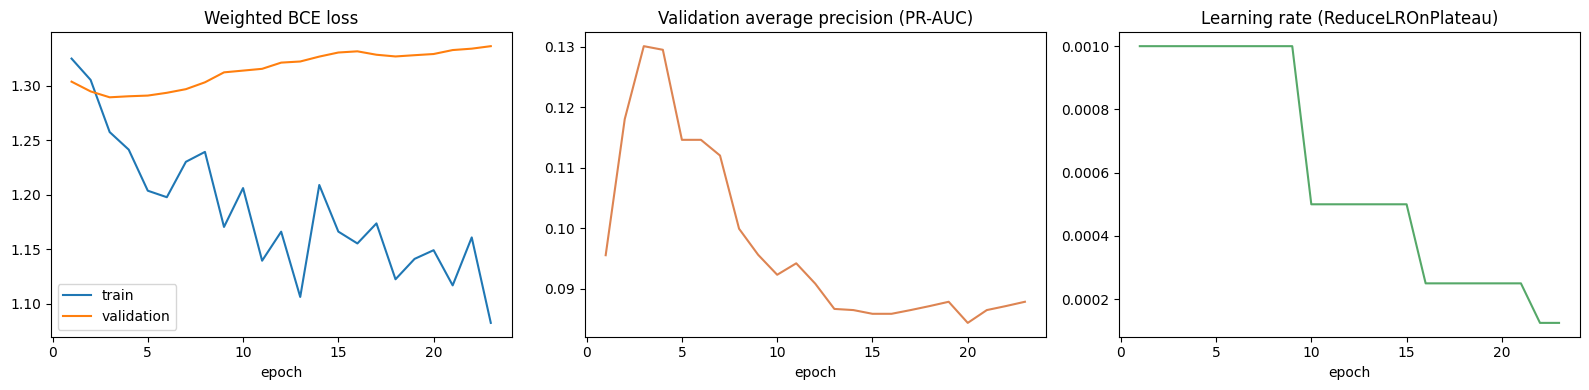

,epoch,train_loss,val_loss,val_average_precision,val_roc_auc,learning_rate
18,19,1.141351,1.328109,0.087869,0.303571,0.000250
19,20,1.149322,1.329192,0.084379,0.275000,0.000250
20,21,1.117051,1.332821,0.086495,0.289286,0.000250
21,22,1.161036,1.334101,0.087157,0.296429,0.000125
22,23,1.082671,1.336384,0.087869,0.303571,0.000125


In [8]:
curves = history.to_frame()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(curves["epoch"], curves["train_loss"], label="train")
axes[0].plot(curves["epoch"], curves["val_loss"], label="validation")
axes[0].set_title("Weighted BCE loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(curves["epoch"], curves["val_average_precision"], color="#DD8452")
axes[1].set_title("Validation average precision (PR-AUC)"); axes[1].set_xlabel("epoch")

axes[2].plot(curves["epoch"], curves["learning_rate"], color="#55A868")
axes[2].set_title("Learning rate (ReduceLROnPlateau)"); axes[2].set_xlabel("epoch")

plt.tight_layout(); plt.show()
curves.tail()

### Reading the curves

Validation loss turning up while training loss keeps falling is the overfitting point —
early stopping restores the weights from the best epoch, so the saved model is *not* the
last epoch's model. On the 300-row sample this happens almost immediately, which is itself
the finding: there is not enough data here for the network to learn anything a forest
cannot.

## 7. Threshold tuning

The network was trained with `pos_weight`, so its output probabilities are deliberately
shifted — a 0.5 cut-off is arbitrary. The threshold is chosen on the **validation** split by
maximising F1, then frozen and applied unchanged to the test split.

tuned decision threshold: 0.56


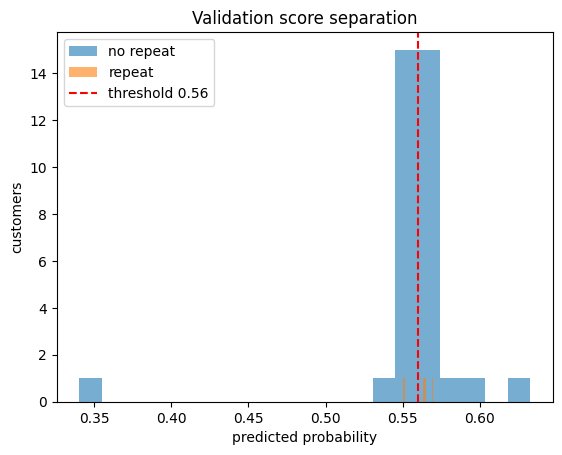

In [9]:
threshold = tune_threshold(mlp, X_val, y_val)
print("tuned decision threshold:", threshold)

val_proba = mlp.predict_proba(X_val)[:, 1]
plt.hist(val_proba[np.asarray(y_val) == 0], bins=20, alpha=0.6, label="no repeat")
plt.hist(val_proba[np.asarray(y_val) == 1], bins=20, alpha=0.6, label="repeat")
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold {threshold}")
plt.xlabel("predicted probability"); plt.ylabel("customers")
plt.title("Validation score separation"); plt.legend(); plt.show()

## 8. Test-set evaluation

In [10]:
dl_metrics = evaluate_mlp(mlp, X_test, y_test)
pd.Series(dl_metrics).round(4)

accuracy             0.3485
balanced_accuracy    0.4917
precision            0.0889
recall               0.6667
f1                   0.1569
roc_auc              0.5264
average_precision    0.1416
dtype: float64

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

test_pred = mlp.predict(X_test)
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, zero_division=0,
                            target_names=["no repeat", "repeat"]))

[[19 41]
 [ 2  4]]
              precision    recall  f1-score   support

   no repeat       0.90      0.32      0.47        60
      repeat       0.09      0.67      0.16         6

    accuracy                           0.35        66
   macro avg       0.50      0.49      0.31        66
weighted avg       0.83      0.35      0.44        66



## 9. Classical ML vs deep learning

The classical models are refit here on train+validation and scored on the same untouched
test split, so the comparison is apples to apples.

In [12]:
comparison = []

for name, model in build_models(SEED).items():
    model.fit(X_train_full, y_train_full)
    comparison.append({"model": name, "family": "classical",
                       **evaluate_fitted(model, X_test, y_test)})

search = tune_random_forest(X_train_full, y_train_full, SEED)
comparison.append({"model": "random_forest_tuned", "family": "classical",
                   **evaluate_fitted(search.best_estimator_, X_test, y_test)})
print("best RF params:", search.best_params_)

comparison.append({"model": "mlp_v1", "family": "deep_learning", **dl_metrics})

table = (pd.DataFrame(comparison)
         .sort_values("average_precision", ascending=False)
         .reset_index(drop=True))
table.round(4)

best RF params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2}


,model,family,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,random_forest_tuned,classical,0.8636,0.5500,0.2000,0.1667,0.1818,0.5514,0.1603
1,random_forest,classical,0.8636,0.5500,0.2000,0.1667,0.1818,0.5806,0.1600
2,mlp_v1,deep_learning,0.3485,0.4917,0.0889,0.6667,0.1569,0.5264,0.1416
3,logistic_regression,classical,0.7273,0.5500,0.1250,0.3333,0.1818,0.4708,0.1372


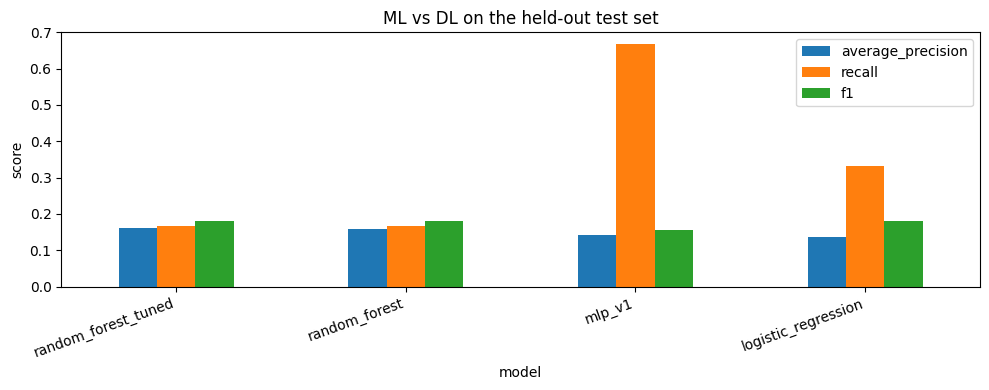

In [13]:
ax = table.set_index("model")[["average_precision", "recall", "f1"]].plot(
    kind="bar", figsize=(10, 4)
)
ax.set_ylabel("score"); ax.set_title("ML vs DL on the held-out test set")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

### Interpretation

On this sample the tuned random forest wins on average precision, and the MLP trades a large
amount of precision for recall — it flags many more customers as likely repeaters than it
should. That is the expected behaviour of a class-weighted network with far too few positive
examples, and it is the honest answer to "did the deep model help?": **not at this data
size**.

What the DL track still demonstrates, and what should be defended in the viva:

* the upgrade is a real experiment with a controlled comparison, not decoration;
* the failure mode is diagnosed (sample size and positive count), not hidden;
* the infrastructure — artifact, threshold, versioning, champion/challenger serving — is in
  place, so re-running on the full dataset is a one-command change with no code edits.

## 10. Save the versioned artifact

The DL model is saved in exactly the same layout as the classical model: a `.joblib` next to
a `.json` holding the feature list, the decision threshold, the architecture and the metrics.
That is what lets `src/models/predict.PredictionTool` load it with no special-casing and
serve it as the **challenger** next to the classical **champion**.

In [14]:
model_path, meta_path = save_dl_artifact(mlp, dl_metrics, history, output_dir="models")
print("saved:", model_path)
print(json.dumps(json.loads(Path(meta_path).read_text()), indent=2)[:900])

saved: models/dl_repeat_purchase_mlp_v1.joblib
{
  "model_name": "dl_repeat_purchase_mlp_v1",
  "model_version": "v1",
  "model_family": "deep_learning",
  "architecture": {
    "type": "MLP",
    "hidden_sizes": [
      64,
      32
    ],
    "dropout": 0.3,
    "output": "single logit + sigmoid"
  },
  "task": "repeat_purchase_prediction",
  "created_at_utc": "2026-09-16T22:48:02.156932+00:00",
  "features": [
    "first_order_revenue",
    "first_order_quantity",
    "first_order_avg_price",
    "first_order_unique_products",
    "first_order_lines",
    "log1p_first_order_revenue",
    "log1p_first_order_quantity",
    "log1p_first_order_avg_price",
    "log1p_first_order_lines"
  ],
  "decision_threshold": 0.56,
  "metrics": {
    "accuracy": 0.3484848484848485,
    "balanced_accuracy": 0.49166666666666664,
    "precision": 0.08888888888888889,
    "recall": 0.6666666666666666,
    "f1": 0.1568627450980392,
    "roc_auc": 0.526


In [15]:
# comparison table for the report and the Streamlit model-registry page
Path("reports").mkdir(exist_ok=True)
table.to_csv("reports/model_comparison.csv", index=False)
Path("reports/model_comparison.json").write_text(json.dumps(comparison, indent=2))
print("wrote reports/model_comparison.csv")

wrote reports/model_comparison.csv


## 11. Serving check

Final proof that the artifact is usable downstream: load it back through the same tool the
agent and the Streamlit app use, and score a real customer.

In [16]:
from src.models.predict import get_default_prediction_tool

tool = get_default_prediction_tool(models_dir="models", db_path="data/retail.db")
result = tool.predict(customer_id="17841").to_dict()

print("champion  :", result["model_version"], "->", result["probability"], result["label"])
print("challenger:", (result.get("challenger") or {}).get("model_version"), "->",
      (result.get("challenger") or {}).get("probability"),
      (result.get("challenger") or {}).get("label"))

champion  : v1 -> 0.056277003750319445 no_repeat
challenger: v1 -> 0.5533495545387268 no_repeat


## 12. Limitations

1. **Sample size.** 261 customers with ~25 positives. Any metric here has a confidence
   interval wide enough to swallow the differences between models.
2. **Feature set.** First-order features only. The obvious upgrades — basket composition,
   time-of-day, country, product-category embeddings — are listed in Future Work.
3. **No calibration.** The probabilities rank customers but are not calibrated, so they must
   not be read as "a 12% chance". The app labels them as scores for that reason.
4. **Static evaluation.** One random split. With the full dataset, repeated stratified CV
   should replace it.
5. **Architecture search.** Width, depth and dropout were fixed by reasoning, not searched.
   A small random search is cheap and should be run on the full data.